Breakdown:

potentials.py

solver.py (The main function)

Then, a fourth file, main_app.py, will bring everything together, handle the MediaPipe input, and plot the results.

Ideas:
 - A clean, modular solver that works for **custom 1D potentials**.

 - Later: **GPU acceleration**, nicer **UI**, maybe interactive widgets. (FUTURE)

 Technical / numerical TODO:

 - Rigorous boundary-condition (BC) enforcement(Dirichlet for infinite well)

 - Orthonormality diagnostic plots (implemented, but can be refined)

 - Convergence analysis

   - e.g. compare $N = 500$ vs $N = 2000$ to see how the discrete operator $\mathbf{D2}$ behaves

 - Analytic solution benchmarking

   - For the infinite square well: compare $E_n$ to

     $$

     E_n = \frac{\hbar^2 \pi^2 n^2}{2 m L^2}

     $$
 - QM Solve Benchmarking 

 - Documentation + modular design


---

## 0. Quantum picture: what am I actually solving?

Before getting lost in matrices and `numpy`, I want to be clear what the **physics problem** is.

In the postulate language of quantum mechanics:

- A **state** of the particle is described by a wavefunction $$\Psi(x)$$ 
  (or more abstractly, a vector $$|\Psi\rangle$$ in a Hilbert space).

- **Observables** (like energy) are represented by **Hermitian operators**.
  
  For a particle in 1D with potential $$V(x)$$, the Hamiltonian operator is

  $$
  \hat{H} = -\frac{\hbar^2}{2m}\frac{d^2}{dx^2} + V(x).
  $$

- The **energy eigenstates** are solutions of

  $$
  \hat{H}\,\psi_n(x) = E_n \,\psi_n(x),
  $$

  with boundary conditions and normalization: $\int |\psi_n(x)|^2 dx = 1.$

Physically:

- Each $\psi_n(x)$ is a **stationary state**: if the system is prepared in $\psi_n$, the probability density $|\psi_n(x,t)|^2$ is independent of time (it only picks up a phase $e^{-iE_n t/\hbar}$).

- The energies $E_n$ are the possible outcomes of a precise **energy measurement**.

- A general state can be expanded as

  $$
  \Psi(x,0) = \sum_n c_n \psi_n(x),
  $$

  and then evolves as

  $$
  \Psi(x,t) = \sum_n c_n \psi_n(x)\,e^{-iE_n t/\hbar}.
  $$

So my numerical solver is really a machine that takes a **chosen potential** $$V(x)$$ and returns:

- The discrete spectrum $$\{E_n\}$$ (energy levels for that potential).
- The corresponding eigenfunctions $$\psi_n(x)$$ (stationary states).

Once I have those, I can in principle build **any** time-dependent solution by choosing coefficients $$c_n$$.


---


# %% [markdown]
### 2.2.1 Infinite wall as a limit of a finite barrier

Another way to see $$\Psi(0) = \Psi(a) = 0$$:

- Start with a **finite** but huge barrier outside $$[0,a]$$:
  
  - $$V(x) = 0$$ for $$0 < x < a$$,
  - $$V(x) = V_0$$ (large but finite) for $$x \le 0$$ and $$x \ge a$$.

- For a bound state with energy $$E < V_0$$, the solution in the barrier region decays exponentially
  (evanescent tail). As $$V_0 \to \infty$$, the decay length goes to zero, and the wavefunction is
  squeezed to exactly zero at the wall.

So the infinite square well is an **idealized limit** where those evanescent tails are completely killed.
In that limit, the physically acceptable states are exactly those that vanish at the boundaries.

### 2.2.2 Probability current and “no leakage”

The boundary conditions are also tied to **probability conservation**.

The probability current in 1D is

$$
j(x) = \frac{\hbar}{m}\,\text{Im}\big(\Psi^*(x)\,\partial_x \Psi(x)\big).
$$

For a particle trapped in the well, there should be **no net probability flow out** of the region.
Taking $$\Psi(0) = \Psi(a) = 0$$ ensures that $$j(0) = j(a) = 0$$, so there is no leakage of probability
through the walls. This is part of making $$\hat{H}$$ self-adjoint with these boundary conditions.

---

# %% [markdown]
### 2.3.1 Physical interpretation: standing waves, nodes, and quantization

The infinite well is a quantum version of a **string fixed at both ends**:

- The boundary conditions $$\Psi(0) = \Psi(a) = 0$$ only allow certain “standing wave” shapes.
- Those shapes are exactly

  $$
  \Psi_n(x) = \sqrt{\frac{2}{a}} \sin\left(\frac{n\pi x}{a}\right),
  $$

  with integer $$n = 1,2,3,\dots$$

Each $$n$$ has:

- $$n-1$$ internal **nodes** (points where $$\Psi_n(x) = 0$$ inside the well).
- Increasing **curvature** of the wavefunction, which corresponds to higher kinetic energy.

This is why the energies scale like

$$
E_n \propto n^2.
$$

The key physics point:

- The **discreteness** of the spectrum (energy quantization) is not put in by hand.
- It **emerges** from:
  - the wave nature of the particle, and
  - the boundary conditions (particle confined in a finite region).

My numerical solver is reproducing that spectrum purely from the operator

$$
\hat{H} = -\frac{\hbar^2}{2m}\frac{d^2}{dx^2} + V(x)
$$

and the boundary conditions encoded in the matrix.
---



## 6. Using the numerical eigenstates as actual quantum states

Once I have the eigenvalues $$E_n$$ and eigenvectors $$\psi_n(x_i)$$ on the grid, I can treat them as
**full quantum states** and compute observables.

On the grid, an integral becomes a sum:

$$
\int f(x)\,dx \approx \sum_i f(x_i)\,\Delta x.
$$

So for a normalized eigenstate $$\psi_n(x)$$:

- Position expectation value:

  $$
  \langle x \rangle_n \approx \sum_i x_i\,|\psi_n(x_i)|^2\,\Delta x.
  $$

- Position variance:

  $$
  \Delta x_n^2 = \langle x^2 \rangle_n - \langle x \rangle_n^2.
  $$

For momentum, in the position representation

$$
\hat{p} = -i\hbar \frac{d}{dx}.
$$

On the grid, I can approximate the derivative with finite differences, e.g.

$$
\left.\frac{d\psi}{dx}\right|_{x_i} \approx \frac{\psi(x_{i+1}) - \psi(x_{i-1})}{2\Delta x},
$$

and then build

$$
\langle p \rangle_n \approx \sum_i \psi_n^*(x_i)\,\left(-i\hbar \frac{d\psi_n}{dx}\bigg|_{x_i}\right)\Delta x.
$$

Similarly for $$\langle p^2 \rangle_n$$, which lets me compute $$\Delta p_n$$ and check the
uncertainty relation numerically:

$$
\Delta x_n\,\Delta p_n \ge \frac{\hbar}{2}.
$$

So the solver is not just a “pretty plotter” of eigenfunctions; it is a tool to compute
**quantum expectation values** for arbitrary observables once they are discretized on the grid.



### 3.5 Operator viewpoint: matrix = Hamiltonian in a finite basis

Conceptually, what I’ve done is:

- Start from the abstract operator equation

  $$
  \hat{H}|\psi_n\rangle = E_n |\psi_n\rangle,
  $$

- Choose the **position basis** sampled on a grid
  $$\{|x_1\rangle, |x_2\rangle, \dots, |x_{N-1}\rangle\},$$
- Represent $$\hat{H}$$ as an $$N\times N$$ **matrix** in that basis using finite differences for the kinetic term
  and a diagonal matrix for $V(x)$.

Because $\hat{H}$ is Hermitian (and my discrete approximation respects that symmetry), the matrix is:

- Real symmetric,
- Has **real** eigenvalues,
- And its eigenvectors form an **orthonormal basis** of the grid space.

This is exactly what I see in the overlap matrix: numerically, it is very close to the identity.


 ## 1. First-principles thinking about $V(x)$



 I want to keep an intuitive, almost classical picture of what the potential means.



 - $V(x)$ describes the **landscape of potential energy** created by the environment.

   You can think of it as a **height map** or a **hill profile**.



 - If $V(x) = 2$ (some constant), then placing a particle there means:

   - The particle "sits" at potential energy 2 (in whatever units I'm using).

   - To move around with total energy $E$, its kinetic energy is $K = E - V(x)$.

   - So if $V$ is larger, the kinetic energy available is smaller for the same $E$.



 - Intuition:

   - $V(x) = 0$ → flat ground

   - $V(x) = 2$ → you are walking on a slope of "height 2"

   - It's easier to move where $V(x)$ is low than where $V(x)$ is high.



 - If $V(x) = \infty$ in some region, then:

   - A particle would need **infinite total energy** to enter that region.

   - In quantum mechanics, this is enforced by making the wavefunction **exactly zero**

     there: the particle simply **cannot exist** in that region.



 This is exactly how the **infinite square well** is defined.

 ## 2. The infinite square well setup



 I imagine an electron (mass $m$) trapped in an infinite square well:



 - Inside the well, for $0 < x < a$:

   $$

   V(x) = 0

   $$

 - Outside the well:

   $$

   V(x) = \infty

   $$



 So the particle is strictly confined to the region $0 < x < a$.

 ### 2.1 Time-Independent Schrödinger Equation (TISE)



 The time-independent Schrödinger equation is



 $$

 H \Psi(x) = E \Psi(x)

 $$



 with the Hamiltonian



 $$

 H = -\frac{\hbar^2}{2m} \frac{d^2}{dx^2} + V(x)

 $$



 For the infinite well region (where $V(x) = 0$), the TISE reduces to:



 $$

 -\frac{\hbar^2}{2m} \frac{d^2 \Psi}{dx^2} = E \Psi

 $$

 ### 2.2 Boundary conditions and physical constraints



 We enforce some conditions on the wavefunction based on physical requirements:



 - Dirichlet boundary conditions:

   $$

   \Psi(0) = \Psi(a) = 0

   $$



   Reason (continuity argument):

   - Schrödinger's equation requires $\Psi(x)$ to be **continuous**.

   - If $\Psi(x)$ had a jump, its second derivative would involve something like a delta function,

     which would blow up the kinetic energy term.

   - Outside the well, where $V(x) = \infty$, the wavefunction must vanish:

     $$

     \Psi(0^-) = 0, \quad \Psi(a^+) = 0

     $$

   - Continuity then implies

     $$

     \Psi(0^+) = 0, \quad \Psi(a^-) = 0

     $$

     so we simply write $\Psi(0) = \Psi(a)=0$.



 - Normalization:

   $$

   \int_{-\infty}^{\infty} |\Psi(x)|^2 \, dx = 1

   $$

   In practice, for the infinite well, this is

   $$

   \int_0^a |\Psi(x)|^2 \, dx = 1.

   $$



 - Probabilistic interpretation:

   - $|\Psi(x)|^2 \, dx$ is the probability of finding the particle between $x$ and $x + dx$.

 ### 2.3 Known analytic solutions (for checking the numerics later)



 For the infinite square well, the analytic solutions are:



 - Wavefunctions:

   $$

   \Psi_n(x) = \sqrt{\frac{2}{a}} \sin\left(\frac{n \pi x}{a}\right), \quad n = 1, 2, 3, \dots

   $$



 - Energy levels:

   $$

   E_n = \frac{\hbar^2 \pi^2 n^2}{2 m a^2}

   $$



 Later in this notebook, I compare the **numerical eigenvalues** to these $E_n$ as a benchmark.

 ## 3. Discretizing the TISE



 To turn the differential equation into something a computer can solve, I:



 - Break the continuous space into small chunks.

 - Use a finite-difference approximation for derivatives.

 - Build a matrix that mimics the second derivative.

 - Solve the resulting **matrix eigenvalue problem**.



 Let me formalize that.

 ### 3.1 Discretizing the derivative



 We start from the usual definition of the derivative:



 $$

 f'(x_i) = \lim_{\Delta x \to 0} \frac{f(x_i + \Delta x) - f(x_i)}{\Delta x}

 $$



 In the code, I *do not* send $\Delta x$ to 0. Instead:



 - I choose a **fixed** grid spacing $\Delta x$.

 - I approximate the derivative using finite differences.



 For the **first derivative**, a forward-difference formula is



 $$

 f'(x_i) \approx \frac{f(x_{i+1}) - f(x_i)}{\Delta x}.

 $$



 This is called the **forward difference** operator. There are also backward and central differences,

 but for the second derivative we usually like the central difference.

 ### 3.2 Building the second derivative $f''(x_i)$



 Because $\Delta x$ is constant, and derivatives are linear, we can say:



 $$

 f''(x_i) \approx \frac{f'(x_{i+1}) - f'(x_i)}{\Delta x}.

 $$



 Now plug in the finite-difference expressions for $f'$:



 $$

 f'(x_{i+1}) \approx \frac{f(x_{i+2}) - f(x_{i+1})}{\Delta x}, \quad

 f'(x_i) \approx \frac{f(x_{i+1}) - f(x_i)}{\Delta x}

 $$



 so



 $$

 f''(x_i) \approx

 \frac{

 \frac{f(x_{i+1}) - f(x_i)}{\Delta x}

 -

 \frac{f(x_i) - f(x_{i-1})}{\Delta x}

 }

 {\Delta x}

 =

 \frac{f(x_{i+1}) - 2 f(x_i) + f(x_{i-1})}{\Delta x^2}.

 $$



 This is the standard **central difference** formula for the second derivative.



 It is exactly what I will use to approximate the operator $\frac{d^2}{dx^2}$ on a grid.

 ### 3.3 Writing the second derivative as a matrix



 Let the grid points be $x_1, x_2, x_3, x_4, \dots$ and the function values be



 $$

 f(x_i) \rightarrow

 f_i =

 \begin{bmatrix}

 f_1 \\

 f_2 \\

 f_3 \\

 f_4 \\

 \vdots

 \end{bmatrix}.

 $$



 Then the central-difference formula for the second derivative gives:



 $$

 \begin{cases}

 f''_1 = \dfrac{f_2 - 2 f_1 + f_0}{(\Delta x)^2}, \\

 f''_2 = \dfrac{f_3 - 2 f_2 + f_1}{(\Delta x)^2}, \\

 f''_3 = \dfrac{f_4 - 2 f_3 + f_2}{(\Delta x)^2}, \\

 \vdots

 \end{cases}

 $$



 The pattern is a stencil $[1, -2, 1]$ sweeping across the vector.



 In matrix form:



 $$

 \frac{d^2}{dx^2} f(x_i) \approx f''(x_i)

 = \frac{1}{(\Delta x)^2}

 \begin{bmatrix}

 -2 & 1 & 0 & 0 & \cdots \\

 1 & -2 & 1 & 0 & \cdots \\

 0 & 1 & -2 & 1 & \cdots \\

 0 & 0 & 1 & -2 & \cdots \\

 \vdots & \vdots & \vdots & \vdots & \ddots

 \end{bmatrix}

 \begin{bmatrix}

 f_1 \\

 f_2 \\

 f_3 \\

 f_4 \\

 \vdots

 \end{bmatrix}.

 $$

 ### 3.4 Schrödinger equation in matrix form



 Starting from



 $$

 -\frac{\hbar^2}{2m} \frac{d^2}{dx^2} \Psi(x) + V(x) \Psi(x) = E \Psi(x),

 $$



 when we discretize, the kinetic term becomes:



 $$

 -\frac{\hbar^2}{2m} \frac{d^2}{dx^2}

 \;\;\longrightarrow\;\;

 -\frac{\hbar^2}{2m}

 \frac{1}{(\Delta x)^2}

 \begin{bmatrix}

 -2 & 1 & 0 & 0 & \cdots \\

 1 & -2 & 1 & 0 & \cdots \\

 0 & 1 & -2 & 1 & \cdots \\

 0 & 0 & 1 & -2 & \cdots \\

 \vdots & \vdots & \vdots & \vdots & \ddots

 \end{bmatrix}.

 $$



 So the matrix version of the TISE is



 $$

 H \Psi = E \Psi

 $$



 with



 $$

 H =

 -\frac{\hbar^2}{2m}

 \frac{1}{(\Delta x)^2}

 \begin{bmatrix}

 -2 & 1 & 0 & 0 & \cdots \\

 1 & -2 & 1 & 0 & \cdots \\

 0 & 1 & -2 & 1 & \cdots \\

 0 & 0 & 1 & -2 & \cdots \\

 \vdots & \vdots & \vdots & \vdots & \ddots

 \end{bmatrix}

 + \text{diag}\big(V(x_1), V(x_2), \dots \big).

 $$



 Note:



 - This matrix acts on the **internal grid points** from $\Psi_1$ to $\Psi_{N-1}$.

 - The boundary values $\Psi_0$ and $\Psi_N$ are fixed by the **Dirichlet BC**:

   $$

   \Psi_0 = \Psi_N = 0.

   $$

 - So the computer only solves for the interior and the BC is enforced by construction.

 With this theory in place, I now build the actual code.

---
---
Quantum Solver Project Documentation: Finite Difference Method for the 1D TISE

Project Overview

This solver utilizes the Finite Difference Method (FDM) to numerically determine the energy eigenvalues ($E_n$) and corresponding eigenstates ($\psi_n$) for a particle of mass $m$ under an arbitrary 1D potential $V(x)$. The central numerical task is the transformation of the continuous Time-Independent Schrödinger Equation (TISE) into a matrix eigenvalue problem on a discrete grid.

$$\left(-\frac{\hbar^2}{2m}\frac{d^2}{dx^2} + V(x)\right)\psi(x) = E\psi(x)$$

The current primary benchmarking potential is the Symmetric Finite Square Well (McIntyre Chapter 5, Context of Problem 5.20).

1. Mapping the Operator to a Matrix $\mathbf{H}$

1.1 The Discrete Hamiltonian

In the position basis, sampled on the discrete grid $\{x_i\}$, the continuous Hamiltonian operator $\hat{H}$ is represented by a large, sparse, real symmetric matrix $\mathbf{H}$.

$$\hat{H} \longrightarrow \mathbf{H} = \mathbf{T} + \mathbf{V}$$

The TISE is thus reduced to the standard linear algebra problem:

$$\mathbf{H}\vec{\psi} = E\vec{\psi}$$

Where:

$\mathbf{H}$ is the $N \times N$ discrete Hamiltonian matrix.

$\vec{\psi}$ is the $N$-dimensional eigenvector containing the wavefunction values $\psi(x_i)$ at the internal grid points.

$E$ is the eigenvalue (the quantized energy).

1.2 The Kinetic Term Matrix $\mathbf{T}$

The second derivative kinetic term ($\frac{d^2}{dx^2}$) is approximated using the central difference formula, which introduces an error of $\mathcal{O}(\Delta x^2)$.

$$\frac{d^2\psi}{dx^2}\bigg|_{x_i} \approx \frac{\psi(x_{i+1}) - 2\psi(x_i) + \psi(x_{i-1})}{(\Delta x)^2}$$

This leads to the tri-diagonal kinetic energy matrix $\mathbf{T}$:

$$\mathbf{T} = -\frac{\hbar^2}{2m} \frac{1}{(\Delta x)^2} \begin{pmatrix}
-2 & 1 & 0 & \cdots \\
1 & -2 & 1 & \cdots \\
0 & 1 & -2 & \cdots \\
\vdots & \vdots & \vdots & \ddots
\end{pmatrix}$$

The symmetry of the resulting matrix $\mathbf{H}$ ensures all eigenvalues $E_n$ are real (a requirement for any physical observable in QM) and the corresponding eigenvectors $\vec{\psi}_n$ are orthogonal.

1.3 Boundary Conditions (BCs) and Spectral Range

For bound state problems (where $E < V_0$ and $\psi \to 0$ as $x \to \pm \infty$), the Dirichlet boundary condition ($\psi(\text{boundary}) = 0$) is applied at the edges of the finite computational box $[-L_{max}, L_{max}]$. This ensures that the numerical solutions model the exponential decay of the physical bound states.

Note on the Spectrum: The FDM diagonalization yields $N$ eigenvalues. These include the discrete bound states ($E_n < V_0$) and a numerical approximation of the continuum states ($E > V_0$). The high-energy continuum states are physically irrelevant and are artifacts of the finite box/grid, often having energies proportional to $\frac{1}{\Delta x^2}$.

2. Benchmark Problem: Finite Square Well Potential

The finite square well is defined by:


$$V(x) = \begin{cases} 0 & \text{for } |x| \le L \\ V_0 & \text{for } |x| > L \end{cases}$$

The analytical solution requires solving a complex transcendental equation. The FDM solver bypasses this difficulty by solving the coupled kinetic and potential energy equations across the entire domain. Bound states are identified simply as those eigenvalues where $E_n < V_0$.

Key Physics Checks (McIntyre 5.20 Context)

Parity Conservation: Since $V(x)=V(-x)$, the Hamiltonian commutes with the parity operator ($\hat{P}\hat{H} = \hat{H}\hat{P}$). Thus, the eigenstates must be simultaneous eigenstates of $\hat{P}$, meaning they are either even or odd.

Ground state ($n=1$): Must be even parity.

First excited state ($n=2$): Must be odd parity.

Wavefunction Penetration: The wavefunction must smoothly transition into the classically forbidden region ($|x| > L$) and decay exponentially (evanescence). The decay constant $\kappa_n$ depends on the barrier strength:


$$\kappa_n = \sqrt{2m(V_0 - E_n)/\hbar^2}$$


States closer to the barrier height ($E_n \to V_0$) penetrate much further.

Approaching the Infinite Limit: By setting a very large $V_0$ (e.g., $V_0=1000$), the numerical results for the lower states should converge to the analytical Infinite Square Well result: $E_n^{ISW} = \frac{\hbar^2 \pi^2 n^2}{2 m (2L)^2}$.

3. Numerical Diagnostics and Convergence

3.1 Orthonormality Check

The discrete eigenstates $\vec{\psi}_n$ must be orthonormal. This is verified by calculating the overlap matrix $\mathbf{O}$ using the discrete representation of the inner product:

$$\mathbf{O}_{mn} = \langle \psi_m | \psi_n \rangle = \sum_{i=1}^N \psi_m(x_i)\psi_n(x_i)\Delta x$$

For perfect orthonormality, $\mathbf{O} = \mathbf{I}$. The off-diagonal elements of $\mathbf{O}$ provide a measure of the numerical error introduced by the diagonalization process and the finite grid approximation.

3.2 Convergence Analysis (Discretization Error)

The discretization error in the eigenvalue $E_n$ is expected to scale quadratically: $E_n^{\text{numerical}} - E_n^{\text{exact}} \sim \mathcal{O}(\Delta x^2)$.

TODO: Execute a convergence run by calculating $E_n$ for several grid sizes $N_k$. Plot $\log(|E_n(\Delta x_k) - E_n^{\text{reference}}|)$ versus $\log(\Delta x_k)$. The slope of this plot should be approximately $2$, confirming the expected convergence rate of the central difference scheme.
(Note: $E_n^{\text{reference}}$ can be the analytical ISW value for very deep wells, or a highly resolved FDM solution for finite wells).

3.3 Quantum Expectation Values and Uncertainty

The discrete wavefunctions allow for the calculation of observables using the discretized integration rule.

Position Expectation:


$$\langle \hat{x} \rangle_n = \sum_i x_i |\psi_n(x_i)|^2 \Delta x$$

Momentum Expectation and Uncertainty: Instead of discretizing the momentum operator $\hat{p} = -i\hbar \frac{d}{dx}$ (which is numerically unstable), $\langle \hat{p}^2 \rangle_n$ can be derived directly from the TISE by leveraging the fact that $\vec{\psi}_n$ is an eigenstate of $\mathbf{H}$:

$$\langle \hat{H} \rangle_n = E_n = \langle \hat{T} \rangle_n + \langle \hat{V} \rangle_n$$


Since $\langle \hat{T} \rangle_n = \langle \hat{p}^2 \rangle_n / (2m)$, we have:


$$\langle \hat{p}^2 \rangle_n = 2m \left(E_n - \sum_i V(x_i) |\psi_n(x_i)|^2 \Delta x \right)$$

The momentum uncertainty $\Delta p_n = \sqrt{\langle \hat{p}^2 \rangle_n - \langle \hat{p} \rangle_n^2}$ can then be computed and verified against the Heisenberg Uncertainty Principle: $\Delta x_n\,\Delta p_n \ge \hbar/2$.

File Breakdown

File

Purpose

Physics Relevance

constants.py

Physical constants and simulation parameters ($\hbar^2/2m$, $L_{max}$, $N$, $\Delta x$).

Defines the fundamental scaling of the TISE.

potentials.py

Function definitions for $V(x)$ (e.g., Finite Well, Harmonic Oscillator).

Encodes the physical configuration and boundary conditions of the problem space.

functions.py

Core computational functions: building $\mathbf{T}$, solve_schrodinger (builds $\mathbf{H}$ and diagonalizes it).

The numerical engine; converts continuous differential operator to discrete linear algebra.

app.py

Streamlit app for user interaction, plotting, and handling diagnostics.

Visualization of eigenstates and verification of key quantum principles.

---
---

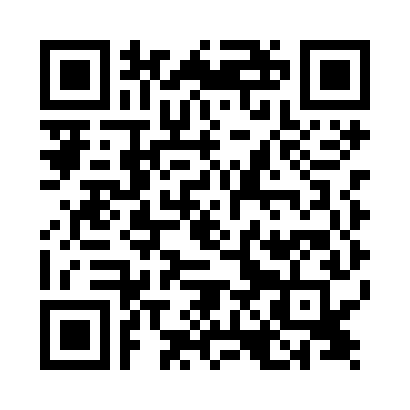

In [1]:
from functions import show_QR
url = "https://huggingface.co/spaces/AhiBucket/Hand-wave?logs=container"
show_QR(url)

### psi_solve


In [2]:
# psi_solve2/ModulatedPresentation.ipynb

### constants
```python 
constants.py
```

In [3]:
L = 50
N_GRID = 2000


from functions import make_grid

x,dx,x_internal = make_grid(L,N_GRID)


### Potentials

```python 
potentials.py
```

In [4]:
from functions import inf_sqaure_well,finite_square_well,gaussian_well,constant

 ### Play Ground for $V(x)$



 Here I choose which potential to use. For now, I will default to the **infinite square well**.



 - I can later uncomment and experiment with:

   - harmonic oscillator + walls,

   - double wells,

   - Gaussian wells,

   - barriers inside wells, etc.

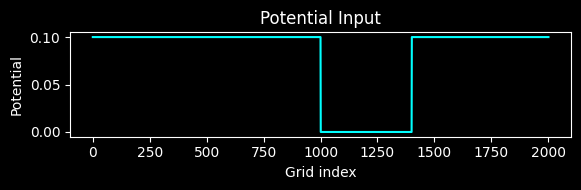

In [5]:
import numpy as np
def custom2(value):
    return value * np.ones_like(x)

#V = inf_sqaure_well(x,-L/2,L/2)


# --- 3. USER PLAYGROUND (Mix and Match Here) ---

# EXAMPLE 1: Half-Harmonic Oscillator (Wall on left, parabola on right)
# V = inf_wall(x, 'left', 2) + harmonic(x, center=5, k=5)

# EXAMPLE 2: A Harmonic Oscillator with a Barrier in the middle
#V = harmonic(x, k=5) + finite_barrier(x, center=L/2, width=0.5, height=50)

# EXAMPLE 3: Double Well (Two Gaussians)
# V = gaussian_well(x, center=3) + gaussian_well(x, center=7)

# Finite wall showing QM TUnneling
# V = finite_square_well(x,-10,10,0.01)

# Let's run Example 1:
#V = inf_wall(x, 'left', 2) + harmonic(x, center=5, k=5)

V = finite_square_well(x,0,10,0.1)


from functions import plot_V

plot_V(V);

# Error with plot Axis...

 For an $N \times N$ matrix (e.g. $4 \times 4$ toy example), the pattern is:



 $$

 \begin{bmatrix}

 1 & 1 & 0 & 0  \\

 1 & 2 & 2 & 0  \\

 0 & 2 & 3 & 3  \\

 0 & 0 & 3 & 4  \\

 \end{bmatrix}

 $$



 - Main diagonal: $N$ elements

 - Off diagonals: each has $N-1$ elements



 Here, my actual matrix is the finite-difference approximation to $\dfrac{d^2}{dx^2}$,

 and I then build the Hamiltonian:



 $$

 - \frac{\hbar^2}{2m} \left( \frac{d^2}{dx^2} \right) \Psi = E \Psi

 $$



 turns into



 $$

 H \Psi = E \Psi,

 $$



 where $H$ is built from $D2$ plus the potential.

In [6]:
hbar = 1
m = 1

from functions import kinetic_operator
T = kinetic_operator(N_GRID, dx, hbar=hbar,m=m)


### Solve

``` python 
solver.py 
```

 The integral



 $$

 \int_{x_1}^{x_N} f(x)\,dx \approx \sum_{i=1}^{N} f(x_i)\,\Delta x

 $$



 is implemented as a Riemann sum on the grid.

In [7]:
from functions import solve

V = finite_square_well(x,-10,10,0.01)


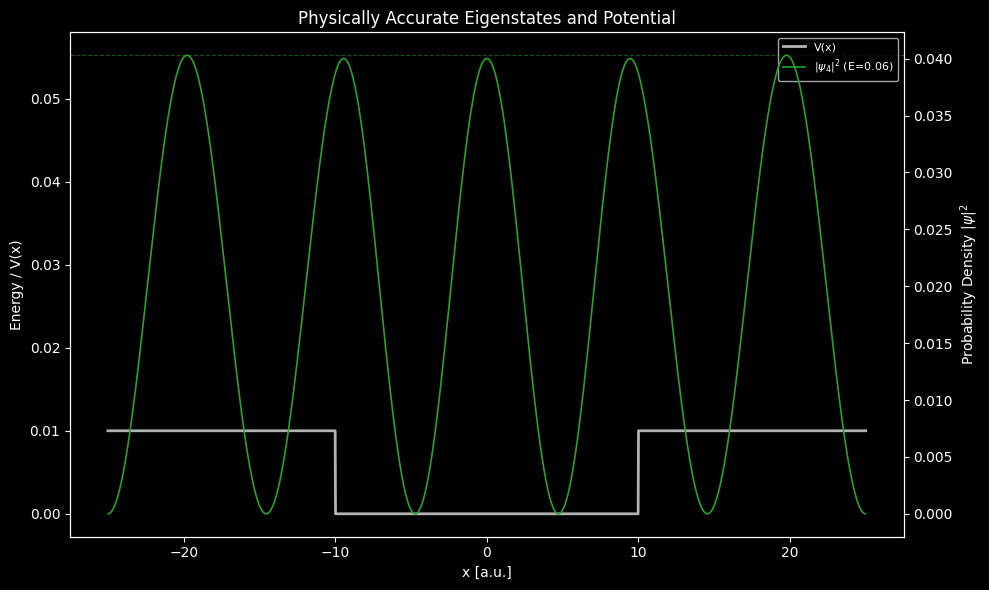

In [8]:
from functions import plot_alive
E, psi = solve(T, V, dx)
plot_alive(E, psi, V, x, no=4);


Wall height is only 0.01 Hartree, which is extremely low! Looking at your image, the energy level E ≈ 0.06 is much higher than the potential barrier (0.01). This means:

The particle has MORE energy than the barrier height
It's not a bound state - it's a scattering state
The wavefunction should oscillate everywhere because E > V everywhere outside the well
The Physics
For exponential decay in classically forbidden regions, you need:

E < V in those regions
For a finite square well, bound states only exist when E < V_barrier



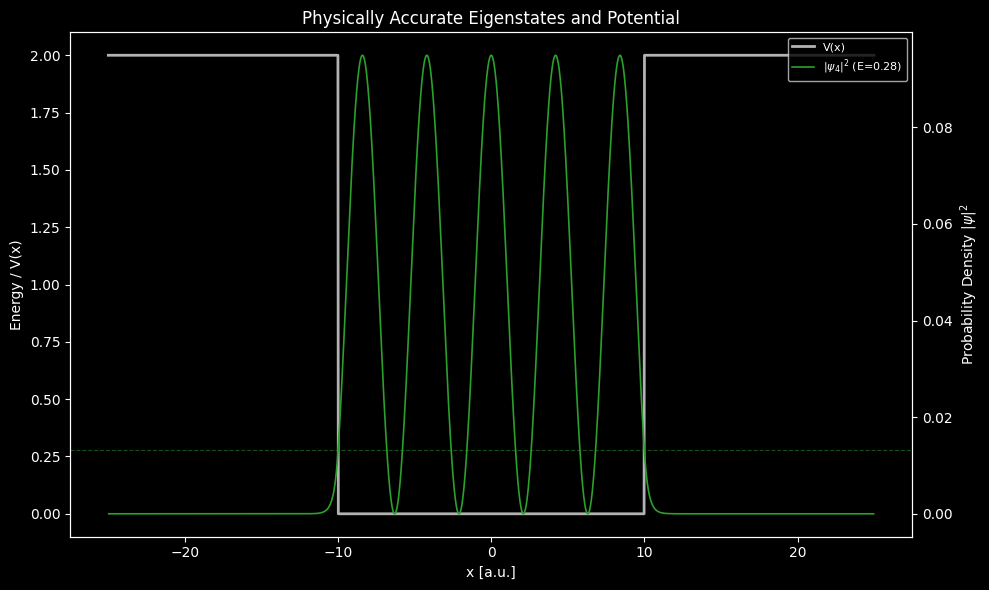

In [9]:
V = finite_square_well(x, -10, 10, 2.0)  # Strong confinement
E, psi = solve(T, V, dx)
plot_alive(E, psi, V, x, no=4);
 


This will create bound states where E < V_barrier, and you'll see the characteristic exponential decay in the classically forbidden regions outside the well.

In [10]:
# Debug 2
bool(0)
print(E)
E.shape
E[-1]

[1.11993441e-02 4.47851424e-02 1.00719809e-01 ... 3.20511873e+03
 3.20518028e+03 3.20518028e+03]


3205.180275687149

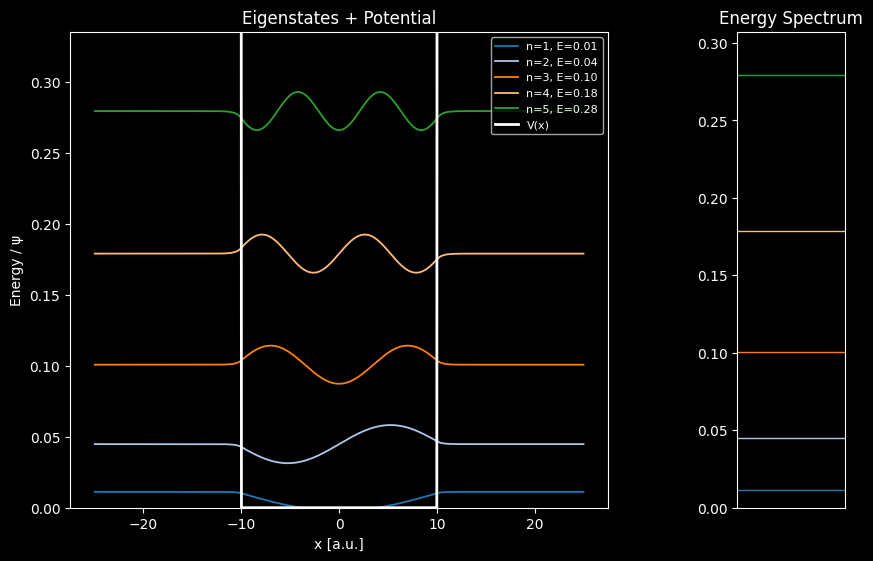

In [11]:
#%matplotlib widget
# Inaccurate Plot for intution (Like the Textbook)

from functions import plot_dead

plot_dead(E, psi, V, x, nos=5);

 ## 4. How do I trust the computer?



 So far:



 - I constructed a Hamiltonian matrix.

 - I asked the computer for its eigenvalues and eigenvectors.

 - I enforced boundary conditions by construction.



 But how do I know these eigenvectors are actually good **approximations to true eigenstates**?



 Two big checks:



 1. **Orthonormality** (linear algebra + normalization)

 2. **Analytic benchmarking** (compare to known formulas)



 ### 4.1 Orthonormality



 If I have two different eigenstates, $\psi_m$ and $\psi_n$ (with $m \neq n$), their inner product must be zero:



 $$

 \langle \psi_m | \psi_n \rangle = 0.

 $$



 This is called **orthogonality**.

 If $m = n$, then the inner product is 1 (if I normalize them properly):



 $$

 \langle \psi_n | \psi_n \rangle = 1.

 $$



 So the **overlap matrix** or **orthonormality matrix** is:



 $$

 \mathbf{S}_{mn} = \langle \psi_m | \psi_n \rangle

 = \int \psi_m^*(x) \psi_n(x) \, dx

 $$



 and in discrete form on the grid:



 $$

 \mathbf{S}_{mn} \approx \sum_i \psi_m(x_i) \psi_n(x_i) \, \Delta x.

 $$



 For properly normalized eigenstates of a Hermitian Hamiltonian, $\mathbf{S}$ should be **the identity matrix**:

 - Diagonal = 1

 - Off-diagonal = 0 (up to small numerical errors)

In [12]:
from functions import check_ortho,show_matrix

overlap_matrix = check_ortho(psi,dx)

show_matrix(overlap_matrix,how="normal")




--- Orthonormality Check (First 20 states) ---
Overlap Matrix should approximate the Identity Matrix:
[[ 1.00000000e+00 -1.77546910e-16  4.92896819e-16  1.99740274e-16
  -4.20446598e-16 -1.99740274e-16 -2.80149057e-17 -2.21933638e-16
   2.77877900e-16 -9.98701371e-17 -9.08638191e-17 -1.22063501e-16
  -2.81039182e-16 -4.29996424e-17 -1.04112667e-17 -7.21284324e-17
  -1.25677508e-17 -6.65800914e-17 -6.74578563e-19 -2.49675343e-17]
 [-1.77546910e-16  1.00000000e+00  8.87734552e-17 -3.96393328e-16
  -1.77546910e-16 -7.35725347e-16 -1.66450229e-16 -6.66724438e-16
  -1.05418478e-16  5.30315433e-17 -2.77417048e-18 -8.52925350e-17
  -3.46771310e-17 -7.43336812e-17  6.84873336e-18 -2.05012282e-16
   1.19636102e-17 -1.82724098e-16  1.00563680e-17 -9.60502344e-17]
 [ 4.92896819e-16  8.87734552e-17  1.00000000e+00  4.43867276e-17
   1.83681698e-16 -1.55353547e-16  2.20834315e-16 -1.88643592e-16
  -5.14321623e-16 -9.98701371e-17  8.45593711e-18 -9.98701371e-17
   1.83129116e-16  0.00000000e+00 -5.

In [13]:

show_matrix(overlap_matrix,how="round",round_value=10)


[[ 1. -0.  0.  0. -0. -0. -0. -0.  0. -0. -0. -0. -0. -0. -0. -0. -0. -0.
  -0. -0.]
 [-0.  1.  0. -0. -0. -0. -0. -0. -0.  0. -0. -0. -0. -0.  0. -0.  0. -0.
   0. -0.]
 [ 0.  0.  1.  0.  0. -0.  0. -0. -0. -0.  0. -0.  0.  0. -0.  0. -0. -0.
  -0. -0.]
 [ 0. -0.  0.  1. -0. -0. -0.  0. -0. -0.  0. -0.  0.  0.  0.  0.  0.  0.
   0.  0.]
 [-0. -0.  0. -0.  1. -0. -0.  0.  0.  0. -0.  0. -0. -0.  0. -0.  0. -0.
   0. -0.]
 [-0. -0. -0. -0. -0.  1.  0. -0. -0.  0. -0. -0. -0.  0.  0. -0.  0.  0.
   0.  0.]
 [-0. -0.  0. -0. -0.  0.  1. -0. -0.  0.  0. -0. -0. -0. -0. -0.  0. -0.
   0.  0.]
 [-0. -0. -0.  0.  0. -0. -0.  1.  0. -0. -0. -0. -0.  0.  0. -0.  0.  0.
   0.  0.]
 [ 0. -0. -0. -0.  0. -0. -0.  0.  1. -0. -0.  0.  0.  0. -0.  0. -0.  0.
  -0.  0.]
 [-0.  0. -0. -0.  0.  0.  0. -0. -0.  1.  0. -0. -0.  0.  0.  0.  0.  0.
   0.  0.]
 [-0. -0.  0.  0. -0. -0.  0. -0. -0.  0.  1. -0. -0.  0.  0.  0.  0.  0.
   0.  0.]
 [-0. -0. -0. -0.  0. -0. -0. -0.  0. -0. -0.  1.  0.  0.  0.  0.

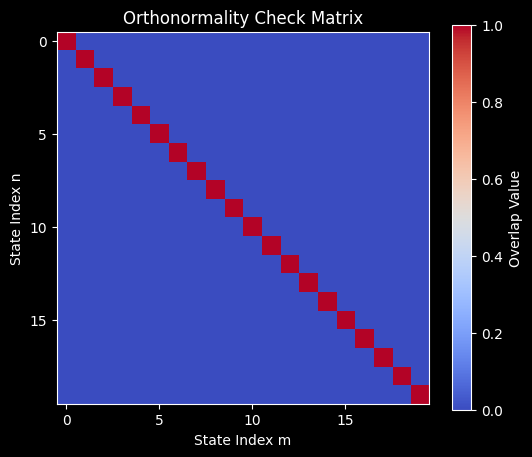

In [14]:
show_matrix(overlap_matrix,how="plot",round_value=10)


 ## 5. Analytical tests (benchmarking)



 Orthonormality tells me the eigenvectors make sense **as a basis**, but I still want to know:



 > Are these the *correct* eigenstates for **this** potential?



 For that, I compare:



 - The **numerical** energy levels from the matrix diagonalization.

 - The **analytic** formulas I already know:

   - Infinite square well energy spectrum.

   - (Optionally) harmonic oscillator spectrum when I switch potential.



 ---



 ### 5.1 Indexing remark



 - In physics, the ground state is $E(n = 1)$ for the infinite square well.

 - In Python, array indices start at 0.



 So:



 - Physically: $n = 1, 2, 3, \dots$

 - In code: `i = 0, 1, 2, ...` corresponds to $n = i + 1$.



 This mismatch is annoying but standard in programming.

 ### 5.2 Infinite square well energies



 The analytic formula:



 $$

 E_{n}^{\text{analytic}} = \frac{\hbar^2 \pi^2 n^2}{2 m L^2}

 $$



 (Here $L$ is the well width.)

In [15]:
from functions import check_ISW_analytic
check_ISW_analytic(E,L,hbar=1.0, m=1.0, max_levels=6)


### ENERGY BENCHMARK: Infinite Square Well ###
Well boundaries: x = [50, 10], Width L = -40
-------------------------------------------------------
| n | Analytic E | Numerical E | % Error |
-------------------------------------------------------
| 1 | 0.003084   | 0.011199    | 263.1139% |
| 2 | 0.012337   | 0.044785    | 263.0147% |
| 3 | 0.027758   | 0.100720    | 262.8462% |
| 4 | 0.049348   | 0.178938    | 262.6034% |
| 5 | 0.077106   | 0.279339    | 262.2782% |
| 6 | 0.111033   | 0.401783    | 261.8589% |
-------------------------------------------------------


(array([0.00308425, 0.01233701, 0.02775826, 0.04934802, 0.07710628,
        0.11103305]),
 array([0.01119934, 0.04478514, 0.10071981, 0.17893758, 0.27933922,
        0.40178301]))

## Convergence Test



In [16]:
# COnvergence Test

 ### 5.3 Harmonic oscillator benchmark



 When I switch $V(x)$ to a harmonic oscillator $V(x) = \tfrac{1}{2} k (x-x_0)^2$ and run the solver:



 - The analytic energy levels are

   $$

   E_n^{\text{HO}} = \left(n + \frac{1}{2}\right) \hbar \omega

   $$

   where $\omega = \sqrt{k/m}$ and $n = 0, 1, 2, \dots$.



 - I can compare the numerical $E_n$ to those values.

 - This is a good **second** test after the infinite square well.

In [17]:
# Assuming Last_k_value, hbar, m, E, and CHECK_N are available
from functions import check_harmonic_analytic
check_harmonic_analytic(E,max_levels=6)

from functions import harmonic

V = harmonic(x=x,k=10,center=10)
check_harmonic_analytic(E,max_levels=6)


Error in harmonic oscillator check: name 'Last_k_value' is not defined

### ENERGY BENCHMARK: Harmonic Oscillator ###
Spring constant k = 10, Center = 0.0, omega = 3.1623
-------------------------------------------------------
| n | Analytic E | Numerical E | % Error |
-------------------------------------------------------
| 0 | 1.581139   | 0.011199    | 99.2917% |
| 1 | 4.743416   | 0.044785    | 99.0558% |
| 2 | 7.905694   | 0.100720    | 98.7260% |
| 3 | 11.067972  | 0.178938    | 98.3833% |
| 4 | 14.230249  | 0.279339    | 98.0370% |
| 5 | 17.392527  | 0.401783    | 97.6899% |
-------------------------------------------------------


(array([ 1.58113883,  4.74341649,  7.90569415, 11.06797181, 14.23024947,
        17.39252713]),
 array([0.01119934, 0.04478514, 0.10071981, 0.17893758, 0.27933922,
        0.40178301]))

In [18]:

import cv2
import mediapipe as mp
# Initialize Grid
# CORRECT CODE
x_full, dx, x_solver = make_grid(L=L, N=N_GRID)

# Build Kinetic Energy Matrix
T = kinetic_operator(N_GRID, dx, hbar=hbar,m=m)

print("Physics Engine Ready.")
print(f"Grid: {N_GRID} points over L={L}")

Physics Engine Ready.
Grid: 2000 points over L=50


In [19]:

# 1. Imports (Make sure these are available in your environment)
import cv2
import numpy as np
import time
import math
import mediapipe as mp 
from IPython.display import display, Image, clear_output
from scipy.interpolate import interp1d # Needed for later potential resizing


from functions import display_params



In [20]:
# Webcam Setup and Capture (Jupyter/Colab)
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(max_num_hands=2, min_detection_confidence=0.7)
drawer = mp.solutions.drawing_utils

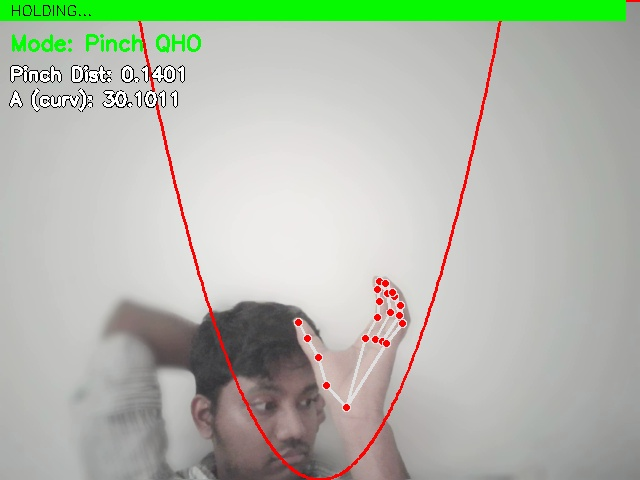

Stable capture triggered and video stream closed.
Potential capture successful.
Solver complete. Found 2000 eigenstates.


In [28]:

from functions import cheese
# 4. Execute Capture
print("Starting camera stream...")
# Assuming A_MIN and A_MAX are defined or hardcoded.
A_MIN = 0
A_MAX = 100 
V_raw_input = cheese(mode='',tune=1, A_MIN=A_MIN, A_MAX=A_MAX) 

def verify():
    if V_raw_input is not None:
        # Use the imported plot_V from your file or define it here
        # plot_V(V_raw_input) 
        print("Potential capture successful.")
    else:
        print("Potential capture failed or was aborted.")


    if V_raw_input is None:
        print("Error: Run the Camera Input cell first to get V_raw_input!")
    else:
        # --- 1. Map Input to Physics Grid (Interpolation & Scaling) ---
        
        # 1.1 Define the internal grid points for the solver
        x_solver = x[1:-1] # Interior points for V_final (length N)
        
        # 1.2 Interpolation: Map the camera's resolution to the solver's grid
        V_interpolated = np.interp(
            x_solver, 
            np.linspace(-L/2, L/2, len(V_raw_input)), # Input X-space
            V_raw_input                               # Input V-values
        )

        # 1.3 Scaling: Convert dimensionless input to energy units
        V_max_height = 100.0 # Heuristic scaling factor
        V_internal = V_interpolated * V_max_height
        
        # 1.4 Prepare V_full (The potential array including the walls, length N+2)
        # The V_full is required by your current 'solve' function signature 
        # to maintain consistency with the inf_sqaure_well definition.
        # We pad the V_internal array with 0s for the walls, knowing that 
        # the Hamiltonian construction will use V_internal (V_full[1:-1]) only.
        V_full = np.pad(V_internal, (1, 1), 'constant', constant_values=0.0)


        # --- 2. Solve H psi = E psi using defined function ---
        # The 'solve' function handles the Hamiltonian construction (T + diag(V)) 
        # and normalization internally.
        try:
            E_vals, psi_vecs = solve(T, V_full, dx)
            print(f"Solver complete. Found {E_vals.size} eigenstates.")
        
        except Exception as e:
            print(f"Error during solve: {e}")
            # Check if the potential is too high, causing numerical instability
            if np.max(V_internal) > 1e9:
                print("Potential may be too steep or high, leading to numerical error.")
            exit()


        # --- 3. Visualization using defined function (or adapted visualization) ---
        
        # The original 'plot_dead' function uses default constants (nos=5).
        # We call it here, passing the calculated results:
        
        # Note: We pass V_full to plot_dead, as it contains the boundary info
        # that your V_clipped logic uses for plotting the potential shape.

        return E_vals,psi_vecs,V_full


E_vals,psi_vecs,V_full = verify()        

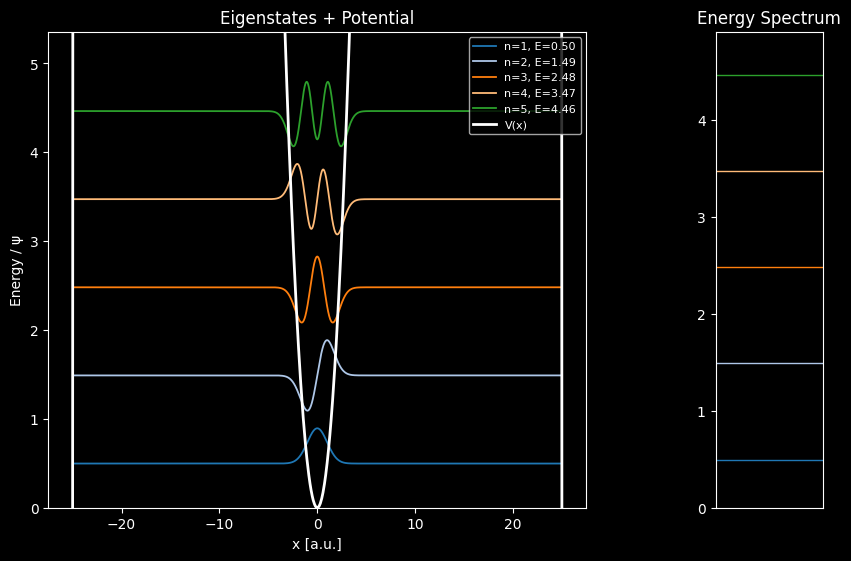

In [29]:
plot_dead(E=E_vals, psi=psi_vecs, V=V_full, x=x, nos=5);

## Verify Against 
```python 
import QM Solve
```

In [30]:
from functions import verify_solver

verify_solver()


                    HAND-WAVE SOLVER VERIFICATION

Testing against analytical solutions for fundamental quantum systems
--------------------------------------------------------------------------------

[TEST 1] INFINITE SQUARE WELL (Particle in a Box)
Domain: L = 20.0 a.u., Grid points: N = 1000

✓ Solved for 1000 eigenstates
  Ground state energy: E[0] = 0.012337 Ha

### ENERGY BENCHMARK: Infinite Square Well ###
Well boundaries: x = [-10.0, 10.0], Width L = 20.0
-------------------------------------------------------
| n | Analytic E | Numerical E | % Error |
-------------------------------------------------------
| 1 | 0.012337   | 0.012337    | 0.0001 % |
| 2 | 0.049348   | 0.049348    | 0.0003 % |
| 3 | 0.111033   | 0.111032    | 0.0007 % |
| 4 | 0.197392   | 0.197389    | 0.0013 % |
| 5 | 0.308425   | 0.308419    | 0.0021 % |
-------------------------------------------------------

[TEST 2] FINITE SQUARE WELL
Domain: L = 20.0 a.u., Grid points: N = 1000
Barrier height: V₀ = 2.0 

---
Deploy:


https://huggingface.co/spaces/AhiBucket/Hand-wave



```python

python -m streamlit run app.py
```

In [ ]:
show_QR(url)